# Powerlaw Chromatic noise fitting example

In [1]:
from enterprise.pulsar import Pulsar
from enterprise.signals.white_signals import MeasurementNoise
from enterprise.signals.gp_signals import TimingModel
from enterprise.signals.signal_base import PTA
from enterprise_extensions.blocks import chromatic_noise_block

from pint.models import get_model_and_toas, get_model
from pint.fitter import WLSFitter
from pint.logging import setup as setup_log
from pint.utils import akaike_information_criterion, plchromnoise_from_cmwavex
from pint import DMconst

from PTMCMCSampler.PTMCMCSampler import PTSampler

import numpy as np
import corner
import matplotlib.pyplot as plt
import astropy.units as u
from copy import deepcopy

Optional mpi4py package is not installed.  MPI support is not available.


In [2]:
setup_log(level="WARNING")

1

## Estimate the optimal number of harmonics using AIC

In [3]:
# I did an initial fit using pintk. 
# sim4.wx1.par is the result of that. 
m, t = get_model_and_toas("sim6.wx1.par", "sim6.tim")

Tspan = t.get_Tspan()

aics = []
idxs = m.components["CMWaveX"].get_indices()

ftr = WLSFitter(t, m)
ftr.fit_toas(maxiter=3)
aic = akaike_information_criterion(ftr.model, t)
aics += [aic]
print(f"{len(idxs)}\t{aic}\t{ftr.resids.chi2_reduced}")

for idx in reversed(idxs):
    if idx == 1:
        m.remove_component("CMWaveX")
    else:
        m.components["CMWaveX"].remove_cmwavex_component(idx)

    ftr = WLSFitter(t, m)
    ftr.fit_toas(maxiter=3)
    aic = akaike_information_criterion(ftr.model, t)
    aics += [aic]
    print(f"{idx-1}\t{aic}\t{ftr.resids.chi2_reduced}")


45	-52508.102852742035	1.0082039082812198
44	-52512.05619923159	1.007167740839811
43	-52512.54628681277	1.0079536456938016
42	-52514.193503980045	1.0081304832483111
41	-52518.120411630145	1.007111517009925
40	-52521.58821279434	1.0063351816520338
39	-52524.08888810019	1.006066554928249
38	-52525.53422575602	1.006350156200759
37	-52527.18634007854	1.0065251877229948
36	-52530.64145583134	1.0057593211980889
35	-52533.214990592685	1.005454447095043
34	-52537.159447428174	1.0044365575949514
33	-52537.324107719614	1.0053863582155291
32	-52538.660798851575	1.0057253380345448
31	-52541.17066379404	1.0054548057986712
30	-52537.115155140644	1.0085883459965956
29	-52511.28548524575	1.0229915014615867
28	-52510.414028792875	1.0244532052639403
27	-52494.15225558075	1.0338655395283305
26	-52479.55439729071	1.0423994203806715
25	-52453.91372132561	1.056610806210658
24	-52437.911094194205	1.0658273984409437
23	-52418.18169038421	1.0769430695748148
22	-52393.55438568571	1.09055408168759
21	-52375.8380

In [13]:
# aics = np.genfromtxt("sim4-aics.txt")[:,1]

d_aics = np.array(aics) - np.min(aics)
nharm_opt = len(d_aics) - 1 - np.argmin(d_aics)

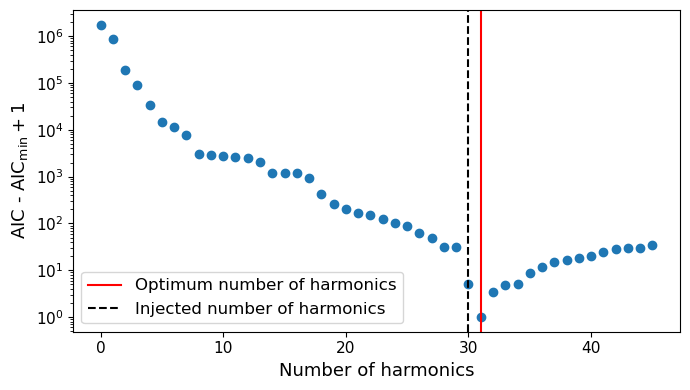

In [14]:
plt.figure(figsize=(7, 4))

plt.scatter(list(reversed(range(len(d_aics)))), d_aics+1)
plt.axvline(nharm_opt, color="red", label="Optimum number of harmonics")
plt.axvline(30, color="black", ls="--", label="Injected number of harmonics")
plt.xlabel("Number of harmonics", fontsize=13)
plt.ylabel("AIC - AIC$_\\min{} + 1$", fontsize=13)
plt.legend(fontsize=12)
plt.yscale("log")
plt.tick_params(axis="both", labelsize=11)
plt.tight_layout()
plt.savefig("sim4-aic.pdf")


In [15]:
nharm_opt

31

## Fit for the CMWaveX parameters

In [16]:
m, t = get_model_and_toas("sim6.wx1.par", "sim6.tim")

Tspan = t.get_mjds().max() - t.get_mjds().min()

idxs = m.components["CMWaveX"].get_indices()
for idx in reversed(idxs):
    if idx > nharm_opt:
        m.components["CMWaveX"].remove_cmwavex_component(idx)

print(m)

# Created: 2024-08-07T15:15:19.525672
# PINT_version: 1.0.1+84.gfa6a9d6a.dirty
# User: Abhimanyu Susobhanan (abhimanyu)
# Host: abhimanyu-HP-Envy-x360-2-in-1-Laptop-15-fh0xxx
# OS: Linux-6.8.0-39-generic-x86_64-with-glibc2.39
# Python: 3.9.19 | packaged by conda-forge | (main, Mar 20 2024, 12:50:21) 
# [GCC 12.3.0]
# Format: pint
PSR                                  SIM6
EPHEM                               DE440
CLOCK                        TT(BIPM2019)
UNITS                                 TDB
START              53000.9999999567114236
FINISH             56985.0000000494553704
DILATEFREQ                              N
DMDATA                                  N
NTOA                                 2000
CHI2                   1914.5791047044263
CHI2R                  1.0082038466058063
TRES                   0.9879392758094687
RAJ                      5:00:00.00000051 1 0.00000140398454215422
DECJ                    14:59:59.99986382 1 0.00012072652274715815
PMRA                          

In [17]:
ftr = WLSFitter(t, m)
ftr.fit_toas(maxiter=5)

print(m)

# Created: 2024-08-07T15:15:26.220895
# PINT_version: 1.0.1+84.gfa6a9d6a.dirty
# User: Abhimanyu Susobhanan (abhimanyu)
# Host: abhimanyu-HP-Envy-x360-2-in-1-Laptop-15-fh0xxx
# OS: Linux-6.8.0-39-generic-x86_64-with-glibc2.39
# Python: 3.9.19 | packaged by conda-forge | (main, Mar 20 2024, 12:50:21) 
# [GCC 12.3.0]
# Format: pint
PSR                                  SIM6
EPHEM                               DE440
CLOCK                        TT(BIPM2019)
UNITS                                 TDB
START              53000.9999999567114236
FINISH             56985.0000000494553704
DILATEFREQ                              N
DMDATA                                  N
NTOA                                 2000
CHI2                   1914.5791047044263
CHI2R                  1.0082038466058063
TRES                   0.9879392758094687
RAJ                      5:00:00.00000051 1 0.00000140398454215422
DECJ                    14:59:59.99986382 1 0.00012072652274715815
PMRA                          

In [18]:
scale = DMconst / 1400**m.TNCHROMIDX.value

In [19]:
idxs = np.array(ftr.model.components["CMWaveX"].get_indices())
a = np.array([(scale*ftr.model[f"CMWXSIN_{idx:04d}"].quantity).to_value("s") for idx in idxs])
da = np.array([(scale*ftr.model[f"CMWXSIN_{idx:04d}"].uncertainty).to_value("s") for idx in idxs])
b = np.array([(scale*ftr.model[f"CMWXCOS_{idx:04d}"].quantity).to_value("s") for idx in idxs])
db = np.array([(scale*ftr.model[f"CMWXCOS_{idx:04d}"].uncertainty).to_value("s") for idx in idxs])

In [20]:
P = (a**2 + b**2) / 2
dP = ((a*da)**2 + (b*db)**2)**0.5

In [21]:
m_pint = plchromnoise_from_cmwavex(ftr.model)

P_pint = m_pint.components["PLChromNoise"].get_noise_weights(t)

In [22]:
m_plrn = get_model("sim6.par")
print(m_plrn)

# Created: 2024-08-07T15:15:42.796957
# PINT_version: 1.0.1+84.gfa6a9d6a.dirty
# User: Abhimanyu Susobhanan (abhimanyu)
# Host: abhimanyu-HP-Envy-x360-2-in-1-Laptop-15-fh0xxx
# OS: Linux-6.8.0-39-generic-x86_64-with-glibc2.39
# Python: 3.9.19 | packaged by conda-forge | (main, Mar 20 2024, 12:50:21) 
# [GCC 12.3.0]
# Format: pint
PSR                                  SIM6
EPHEM                               DE440
CLOCK                        TT(BIPM2019)
UNITS                                 TDB
DILATEFREQ                              N
DMDATA                                  N
NTOA                                    0
RAJ                      5:00:00.00000000 1 0.00000000000000000000
DECJ                    15:00:00.00000000 1 0.00000000000000000000
PMRA                                  0.0
PMDEC                                 0.0
PX                                    0.0
F0                                  100.0 1 0.0
F1                                 -1e-15 1 0.0
PEPOCH            

In [23]:
P_plrn = m_plrn.components["PLChromNoise"].get_noise_weights(t)

## Bayesian analysis using ENTERPRISE

In [24]:
psr = Pulsar("sim6.par", "sim6.tim", timing_package="pint")

In [40]:
wn = MeasurementNoise(efac=1)
tm = TimingModel()
rn = chromatic_noise_block(components=nharm_opt, idx=m.TNCHROMIDX.value, gp_kernel="diag")

In [41]:
model = wn + tm + rn

In [42]:
pta = PTA([model(psr)])

In [43]:
pta.param_names

['SIM6_chrom_gp_gamma', 'SIM6_chrom_gp_log10_A']

In [44]:
ndim = len(pta.param_names)
x0 = np.array([p.sample() for p in pta.params])
cov = np.diag(np.ones(ndim)) * 1e-4
outdir = "chains/sim6/"
Niter = 100000

In [45]:
sampler = PTSampler(
    ndim,
    pta.get_lnlikelihood,
    pta.get_lnprior,
    cov,
    outDir=outdir,
)

In [46]:
sampler.sample(
    x0,
    Niter,
)

Finished 10.00 percent in 2.416999 s Acceptance rate = 0.46592Adding DE jump with weight 20
Finished 100.00 percent in 22.194199 s Acceptance rate = 0.50135
Run Complete


In [47]:
chain = np.genfromtxt(f"{outdir}/chain_1.txt")
burn = chain.shape[0]//5
burned_chain = chain[burn:, :-4]

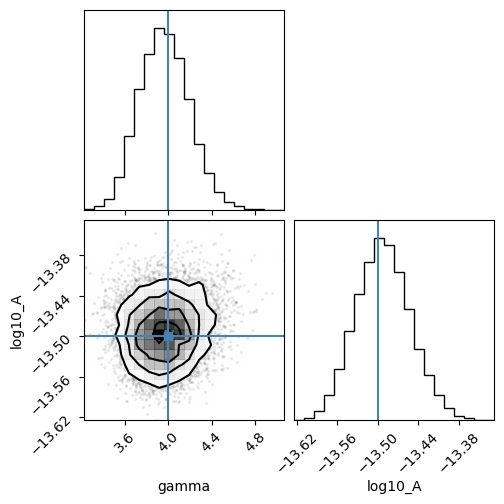

In [48]:
fig = corner.corner(
    burned_chain, 
    labels=["gamma", "log10_A"], 
    truths=[m_plrn.TNCHROMGAM.value, m_plrn.TNCHROMAMP.value],
)

In [49]:
gamma_e, log10_A_e = np.median(burned_chain, axis=0)

m_ent = deepcopy(m_plrn)
m_ent.TNCHROMAMP.value = log10_A_e
m_ent.TNCHROMGAM.value = gamma_e
P_ent = m_ent.components["PLChromNoise"].get_noise_weights(t)

In [50]:
f0 = (1/Tspan).to_value("Hz")

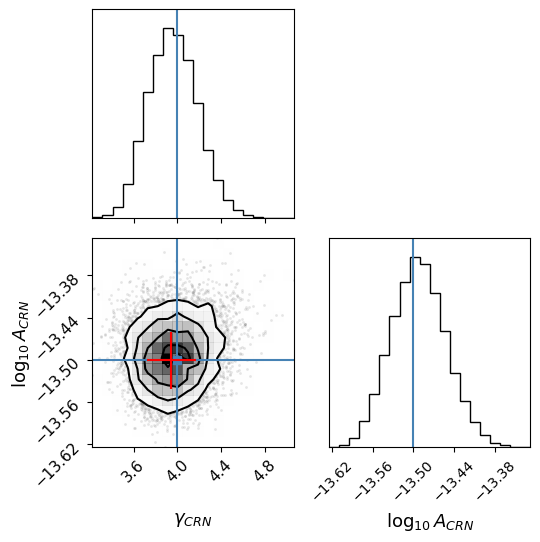

In [51]:
fig = corner.corner(
    burned_chain, 
    labels=["$\\gamma_{CRN}$", "$\\log_{10} A_{CRN}$"], 
    truths=[m_plrn.TNCHROMGAM.value, m_plrn.TNCHROMAMP.value],
    label_kwargs={"fontsize": 13}
)

plt.subplot(223)
plt.errorbar([m_pint.TNCHROMGAM.value], [m_pint.TNCHROMAMP.value], xerr=[m_pint.TNCHROMGAM.uncertainty_value], yerr=[m_pint.TNCHROMAMP.uncertainty_value], color="red")

plt.subplot(223)
plt.tick_params(axis="both", labelsize=11)

plt.tight_layout()

plt.savefig("sim6-param.pdf")

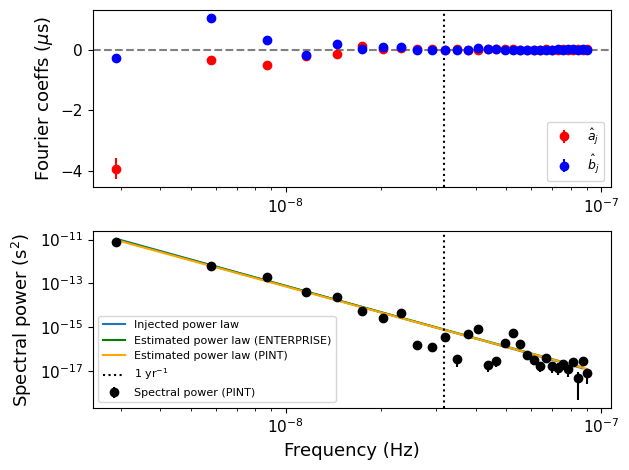

In [62]:
f0 = (1/Tspan).to_value("Hz")
fyr = (1 / u.year).to_value("Hz")

plt.subplot(211)
plt.errorbar(idxs*f0, b*1e6, db*1e6, ls="", marker="o", label="$\\hat{a}_j$", color="red")
plt.errorbar(idxs*f0, a*1e6, da*1e6, ls="", marker="o", label="$\\hat{b}_j$", color="blue")
plt.axvline(fyr, color="black", ls="dotted")
plt.axhline(0, color="grey", ls="--")
plt.ylabel("Fourier coeffs ($\mu$s)", fontsize=13)
plt.xscale("log")
plt.legend(fontsize=9)
plt.tick_params(axis="both", labelsize=11)


plt.subplot(212)
plt.errorbar(idxs*f0, P, dP, ls="", marker="o", label="Spectral power (PINT)", color="k")
plt.plot(idxs[:30]*f0, P_plrn[::2], label="Injected power law")
plt.plot(idxs[:30]*f0, P_ent[::2], label="Estimated power law (ENTERPRISE)", color="green")
plt.plot(idxs*f0, P_pint[::2], label="Estimated power law (PINT)", color="orange")
plt.axvline(fyr, color="black", ls="dotted", label="1 yr$^{-1}$")
plt.xscale("log")
plt.yscale("log")
plt.ylabel("Spectral power (s$^2$)", fontsize=13)
plt.xlabel("Frequency (Hz)", fontsize=13)
plt.legend(fontsize=8)
plt.tick_params(axis="both", labelsize=11)

plt.tight_layout()

plt.savefig("sim6-spec.pdf")

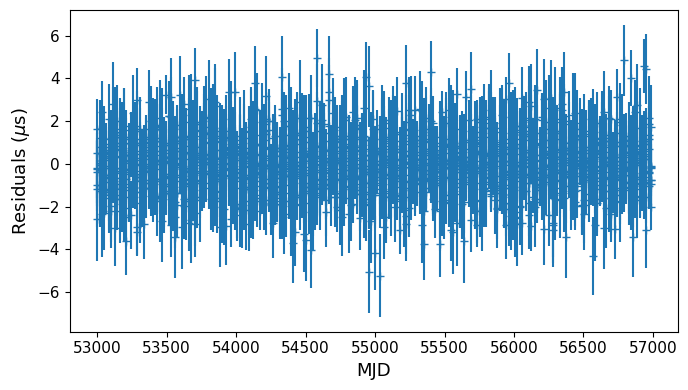

In [43]:
plt.figure(figsize=(7, 4))
plt.errorbar(ftr.toas.get_mjds(), ftr.resids.time_resids.to("us"), ftr.resids.get_data_error().to("us"), ls="", marker="+")
plt.ylabel("Residuals ($\\mu$s)", fontsize=13)
plt.xlabel("MJD", fontsize=13)
plt.tick_params(axis="both", labelsize=11)
plt.tight_layout()
plt.savefig("sim4-resids.pdf")